# 13 - Transfer learning: pretrained backbones vs. from-scratch CitrusNet

First use of pretrained ImageNet backbones in this project. Three models (ResNet50, EfficientNet-B0, DenseNet121) are fine-tuned in two phases and compared against each other; comparison against CitrusNet itself happens in the evaluation notebook.

## Part A - citrus_transfer.py

Backbone construction and freeze/unfreeze helpers, written to disk so later notebooks can import them the same way citrus_common.py and citrus_train.py are used.

In [1]:
%%writefile citrus_transfer.py
"""
citrus_transfer.py

Helpers for the transfer-learning experiments: building pretrained backbones
(ResNet50, EfficientNet-B0, DenseNet121) with a CitrusNet-matching classifier
head, and freezing/unfreezing utilities for two-phase fine-tuning.
"""

import torch.nn as nn
from torchvision.models import (
    resnet50, ResNet50_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    densenet121, DenseNet121_Weights,
)

# Pretrained backbones expect ImageNet normalization, not this project's
# dataset-specific stats (see notebook 13 for the reasoning).
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

_SUPPORTED_ARCHITECTURES = ("resnet50", "efficientnet_b0", "densenet121")


def _make_head(in_features: int, num_classes: int) -> nn.Sequential:
    """Same head design used by CitrusNet's classifier, for a fair comparison."""
    return nn.Sequential(
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes),
    )


def build_model(architecture: str, num_classes: int = 4) -> nn.Module:
    """Load a pretrained backbone and swap in the CitrusNet-style head."""
    if architecture == "resnet50":
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        model.fc = _make_head(model.fc.in_features, num_classes)
    elif architecture == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        # classifier is Sequential(Dropout, Linear) -- the Linear holds in_features
        in_features = model.classifier[-1].in_features
        model.classifier = _make_head(in_features, num_classes)
    elif architecture == "densenet121":
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = _make_head(model.classifier.in_features, num_classes)
    else:
        raise ValueError(
            f"Unsupported architecture {architecture!r}; expected one of "
            f"{_SUPPORTED_ARCHITECTURES}."
        )
    return model


def _get_head(model: nn.Module, architecture: str) -> nn.Module:
    if architecture == "resnet50":
        return model.fc
    elif architecture in ("efficientnet_b0", "densenet121"):
        return model.classifier
    else:
        raise ValueError(
            f"Unsupported architecture {architecture!r}; expected one of "
            f"{_SUPPORTED_ARCHITECTURES}."
        )


def freeze_backbone(model: nn.Module, architecture: str) -> None:
    """Freeze every parameter except the new classifier head."""
    head = _get_head(model, architecture)
    head_param_ids = {id(p) for p in head.parameters()}
    for p in model.parameters():
        p.requires_grad = id(p) in head_param_ids


def unfreeze_all(model: nn.Module) -> None:
    """Make every parameter trainable again, for the full fine-tune phase."""
    for p in model.parameters():
        p.requires_grad = True


def count_trainable_params(model: nn.Module):
    """Return (trainable_count, total_count), computed from requires_grad."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total

Overwriting citrus_transfer.py


Import it back and run a quick sanity check before using it for real.

In [2]:
import citrus_transfer
from citrus_transfer import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    build_model,
    freeze_backbone,
    unfreeze_all,
    count_trainable_params,
)

print("IMAGENET_MEAN:", IMAGENET_MEAN)
print("IMAGENET_STD:", IMAGENET_STD)

_test_model = build_model("resnet50")
freeze_backbone(_test_model, "resnet50")
trainable, total = count_trainable_params(_test_model)
print(f"resnet50 with frozen backbone: {trainable:,} trainable / {total:,} total")

unfreeze_all(_test_model)
trainable, total = count_trainable_params(_test_model)
print(f"resnet50 after unfreeze_all:   {trainable:,} trainable / {total:,} total")

del _test_model

IMAGENET_MEAN: (0.485, 0.456, 0.406)
IMAGENET_STD: (0.229, 0.224, 0.225)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\kulje/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [01:57<00:00, 875kB/s] 


resnet50 with frozen backbone: 262,788 trainable / 23,770,820 total
resnet50 after unfreeze_all:   23,770,820 trainable / 23,770,820 total


## Part B - fine-tuning three pretrained backbones

Imports for the training run.

In [3]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from citrus_common import get_transforms, CitrusLeafDataset
from citrus_train import set_seed, fit
from citrus_transfer import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    build_model,
    freeze_backbone,
    unfreeze_all,
    count_trainable_params,
)

Seed and device.

In [4]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


Datasets and loaders. All three backbones share the same input pipeline, so train/val are built once and reused. Note this uses IMAGENET_MEAN/STD, not this project's own normalization_stats.json -- the pretrained conv filters were learned under ImageNet's statistics, so that's the correct normalization here even though every other notebook in this project uses the dataset's own mean/std.

In [5]:
train_transform = get_transforms(augment=True, mean=IMAGENET_MEAN, std=IMAGENET_STD, size=224)
val_transform = get_transforms(augment=False, mean=IMAGENET_MEAN, std=IMAGENET_STD, size=224)

train_dataset = CitrusLeafDataset("processed/224", split="train", transform=train_transform)
val_dataset = CitrusLeafDataset("processed/224", split="val", transform=val_transform)

print("train:", len(train_dataset), "val:", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

train: 1131 val: 242


Class-weighted loss, same weights used for CitrusNet.

In [6]:
class_weights = torch.tensor([0.9921, 0.9240, 1.1880, 0.9363], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Two-phase fine-tuning for each backbone: phase 1 trains only the new classifier head with the backbone frozen (warmup), phase 2 unfreezes everything and fine-tunes end to end at a 10x lower learning rate. Phase 1's best checkpoint is loaded before phase 2 starts.

In [7]:
ARCHITECTURES = ["resnet50", "efficientnet_b0", "densenet121"]

os.makedirs("checkpoints", exist_ok=True)


def combine_histories(hist1, hist2):
    n1 = len(hist1["train_loss"])
    n2 = len(hist2["train_loss"])
    rows = []
    for i in range(n1):
        rows.append({
            "epoch": i + 1,
            "phase": 1,
            "train_loss": hist1["train_loss"][i],
            "train_acc": hist1["train_acc"][i],
            "val_loss": hist1["val_loss"][i],
            "val_acc": hist1["val_acc"][i],
            "lr": hist1["lr"][i],
        })
    for i in range(n2):
        rows.append({
            "epoch": n1 + i + 1,
            "phase": 2,
            "train_loss": hist2["train_loss"][i],
            "train_acc": hist2["train_acc"][i],
            "val_loss": hist2["val_loss"][i],
            "val_acc": hist2["val_acc"][i],
            "lr": hist2["lr"][i],
        })
    return pd.DataFrame(rows)


all_histories = {}
total_params_by_arch = {}

for architecture in ARCHITECTURES:
    print("\n" + "=" * 60)
    print(architecture)
    print("=" * 60)

    # Phase 1: frozen backbone, head-only warmup
    set_seed(42)
    model = build_model(architecture)
    freeze_backbone(model, architecture)
    model = model.to(device)

    trainable, total = count_trainable_params(model)
    print(f"[phase 1] trainable params: {trainable:,} / {total:,}")

    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    hist1 = fit(
        model, train_loader, val_loader, criterion, optimizer, device,
        max_epochs=15, early_stop_patience=5, scheduler=scheduler,
        checkpoint_path=f"checkpoints/tl_{architecture}_phase1_best.pt",
        verbose=True,
    )

    model.load_state_dict(torch.load(f"checkpoints/tl_{architecture}_phase1_best.pt", map_location=device))

    # Phase 2: full fine-tune at a lower learning rate
    unfreeze_all(model)
    trainable, total = count_trainable_params(model)
    print(f"[phase 2] trainable params: {trainable:,} / {total:,}")
    total_params_by_arch[architecture] = total

    optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    hist2 = fit(
        model, train_loader, val_loader, criterion, optimizer, device,
        max_epochs=50, early_stop_patience=10, scheduler=scheduler,
        checkpoint_path=f"checkpoints/tl_{architecture}_phase2_best.pt",
        verbose=True,
    )

    df_hist = combine_histories(hist1, hist2)
    df_hist.to_csv(f"history_tl_{architecture}.csv", index=False)
    all_histories[architecture] = df_hist

    best_row = df_hist.loc[df_hist["val_loss"].idxmin()]
    n1 = len(hist1["train_loss"])
    n2 = len(hist2["train_loss"])
    best_loss = best_row["val_loss"]
    best_acc = best_row["val_acc"]
    best_epoch = int(best_row["epoch"])
    print(
        f"{architecture}: phase1={n1} epochs, phase2={n2} epochs, "
        f"best_val_loss={best_loss:.5f}, best_val_acc={best_acc:.4f}, "
        f"best_epoch={best_epoch}"
    )


resnet50
[phase 1] trainable params: 262,788 / 23,770,820
epoch   1  train_loss 0.8403  train_acc 0.7462  val_loss 0.6961  val_acc 0.7727  lr 1.00e-03
epoch   2  train_loss 0.3392  train_acc 0.9098  val_loss 0.4175  val_acc 0.8554  lr 1.00e-03
epoch   3  train_loss 0.1891  train_acc 0.9576  val_loss 0.2508  val_acc 0.9298  lr 1.00e-03
epoch   4  train_loss 0.1441  train_acc 0.9629  val_loss 0.2169  val_acc 0.9380  lr 1.00e-03
epoch   5  train_loss 0.1059  train_acc 0.9699  val_loss 0.2088  val_acc 0.9380  lr 1.00e-03
epoch   6  train_loss 0.0777  train_acc 0.9814  val_loss 0.1767  val_acc 0.9421  lr 1.00e-03
epoch   7  train_loss 0.0752  train_acc 0.9805  val_loss 0.2273  val_acc 0.9091  lr 1.00e-03
epoch   8  train_loss 0.0513  train_acc 0.9894  val_loss 0.3060  val_acc 0.8760  lr 1.00e-03
epoch   9  train_loss 0.0570  train_acc 0.9867  val_loss 0.1755  val_acc 0.9298  lr 1.00e-03
epoch  10  train_loss 0.0468  train_acc 0.9876  val_loss 0.2011  val_acc 0.9256  lr 1.00e-03
epoch  11  

Hyperparameter table, one row per model.

In [8]:
hyperparams_df = pd.DataFrame([
    {
        "architecture": arch,
        "pretrained_on": "ImageNet1K",
        "phase1_lr": 1e-3,
        "phase1_max_epochs": 15,
        "phase1_early_stop_patience": 5,
        "phase2_lr": 1e-4,
        "phase2_max_epochs": 50,
        "phase2_early_stop_patience": 10,
        "batch_size": 16,
        "weight_decay": 1e-4,
        "dropout": 0.5,
        "optimizer": "Adam",
        "scheduler": "ReduceLROnPlateau",
        "total_params": total_params_by_arch[arch],
        "classifier_head": "Linear(in,128)-ReLU-Dropout(0.5)-Linear(128,4)",
    }
    for arch in ARCHITECTURES
])

hyperparams_df.to_csv("hyperparameters_transfer_learning.csv", index=False)
hyperparams_df

,architecture,pretrained_on,phase1_lr,phase1_max_epochs,phase1_early_stop_patience,phase2_lr,phase2_max_epochs,phase2_early_stop_patience,batch_size,weight_decay,dropout,optimizer,scheduler,total_params,classifier_head
0,resnet50,ImageNet1K,0.001,15,5,0.0001,50,10,16,0.0001,0.5,Adam,ReduceLROnPlateau,23770820,"Linear(in,128)-ReLU-Dropout(0.5)-Linear(128,4)"
1,efficientnet_b0,ImageNet1K,0.001,15,5,0.0001,50,10,16,0.0001,0.5,Adam,ReduceLROnPlateau,4172032,"Linear(in,128)-ReLU-Dropout(0.5)-Linear(128,4)"
2,densenet121,ImageNet1K,0.001,15,5,0.0001,50,10,16,0.0001,0.5,Adam,ReduceLROnPlateau,7085572,"Linear(in,128)-ReLU-Dropout(0.5)-Linear(128,4)"


Validation curves, all three models overlaid on the same axes.

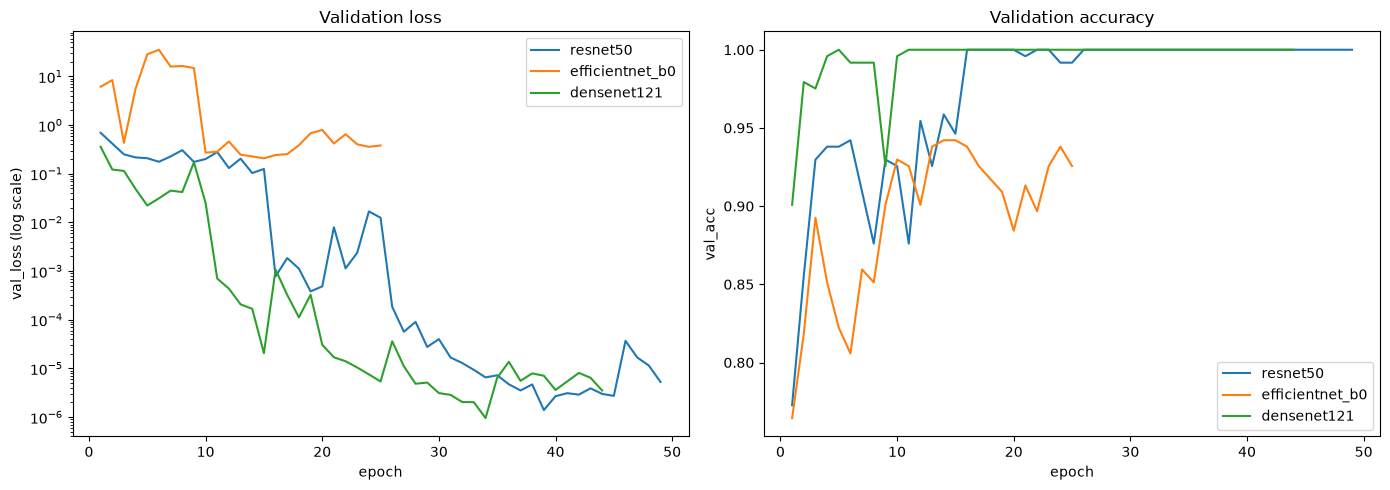

In [9]:
colors = {"resnet50": "tab:blue", "efficientnet_b0": "tab:orange", "densenet121": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for arch in ARCHITECTURES:
    df = all_histories[arch]
    axes[0].plot(df["epoch"], df["val_loss"], label=arch, color=colors[arch])
    axes[1].plot(df["epoch"], df["val_acc"], label=arch, color=colors[arch])

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("val_loss (log scale)")
axes[0].set_title("Validation loss")
axes[0].legend()

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val_acc")
axes[1].set_title("Validation accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Final comparison.

In [10]:
print("Summary")
print("-" * 40)
for arch in ARCHITECTURES:
    df = all_histories[arch]
    best_row = df.loc[df["val_loss"].idxmin()]
    total_epochs = int(df["epoch"].max())
    best_loss = best_row["val_loss"]
    best_acc = best_row["val_acc"]
    print(
        f"{arch}: best_val_loss={best_loss:.5f}, best_val_acc={best_acc:.4f}, "
        f"total_epochs={total_epochs}"
    )

fastest_epoch = {}
for arch in ARCHITECTURES:
    df = all_histories[arch]
    reached = df[df["val_acc"] >= 0.99]
    fastest_epoch[arch] = int(reached["epoch"].min()) if not reached.empty else None

reached_archs = {a: e for a, e in fastest_epoch.items() if e is not None}
if reached_archs:
    fastest_arch = min(reached_archs, key=reached_archs.get)
    print(f"\nFastest to 99% val accuracy: {fastest_arch} (epoch {reached_archs[fastest_arch]})")
else:
    print("\nNone of the three models reached 99% val accuracy.")

lowest_loss_arch = min(ARCHITECTURES, key=lambda a: all_histories[a]["val_loss"].min())
lowest_loss_val = all_histories[lowest_loss_arch]["val_loss"].min()
print(f"Lowest best_val_loss: {lowest_loss_arch} ({lowest_loss_val:.5f})")

Summary
----------------------------------------
resnet50: best_val_loss=0.00000, best_val_acc=1.0000, total_epochs=49
efficientnet_b0: best_val_loss=0.20769, best_val_acc=0.9421, total_epochs=25
densenet121: best_val_loss=0.00000, best_val_acc=1.0000, total_epochs=44

Fastest to 99% val accuracy: densenet121 (epoch 4)
Lowest best_val_loss: densenet121 (0.00000)
